## BadNet Digit Recognition Attack (MNIST Dataset)

- We randomly select a fraction of the MNIST training dataset (e.g. 10%)
- We then apply the backdoor pattern to these selected images
- We change the ground truth label to the attacker's target. For a "single target attack," this means changing of the backdoored image to a specific target class (e.g. labeling digit i as digit j)

- try CIFAR-10 dataset (DONE)
- reduce poison rate to 1% (DONE)
- make it more practical (too simple)
- understand how backdoor bench works
- read about influence functions in machine learning and how they work (we. will take samples with lower influence - how can influence functions help create camo samples)
- implement one proof of concept model



Title: Parasitic Backdoor Attacks via Compliance-Driven Machine Unlearning

Description: Machine Unlearning is a critical component of modern Deep Neural Network (DNN) deployment, necessitated by regulations like GDPR (“Right to be Forgotten”) and DMCA copyright laws. Recent research has demonstrated that this process can be exploited to activate latent backdoors, where the removal of specific data triggers malicious functionality. However, existing strategies typically rely on injecting artificial “camouflage” or “noise” data to suppress the backdoor during training, which introduces statistical anomalies into the dataset.
In this project, we will develop a novel parasitic backdoor attack that fundamentally differs from these approaches by eliminating the need for artificial camouflage. Instead of masking the backdoor with noise, this method uses Gradient Locking to mathematically bind the backdoor’s suppression to specific, high-value “Host” data (e.g., copyrighted images or distinct clean samples) already inherent to the training set. The backdoor remains dormant only because the strong gradients of the Host data actively cancel out the malicious gradients during training. Crucially, the subsequent unlearning of these Host samples removes this necessary counter-force, effectively “unlocking” the malicious gradients and activating the backdoor. We aim to demonstrate that complying with legitimate legal requests inherently triggers the attack, forcing an unavoidable choice between regulatory violation and model compromise.

Required Skills: Python, PyTorch, Deep Learning fundamentals (specifically gradient descent and loss landscapes).

Preferred Skills: Familiarity with Backdoor Attacks and Machine Unlearning.

Deliverables:

2 weeks deliverable: Set up the experimental environment with standard image classification models. Implement and verify a baseline Machine Unlearning pipeline to ensure “Host” images can be effectively removed upon request.
6 weeks deliverable: Implement the “Parasitic Poison Generation” module. Create poison samples that satisfy the gradient cancellation objective against selected Host images. Produce an initial analysis showing that the backdoor remains dormant while the Host data is present in the model.
10 weeks deliverable:
Execute the full attack lifecycle: Trigger the backdoor by simulating a GDPR takedown request for the Host data and benchmark the post-unlearning Attack Success Rate.
A 6-page report detailing the methodology and experimental results.

In [4]:
!pip install torchvision

Defaulting to user installation because normal site-packages is not writeable


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import numpy as np
import copy

ModuleNotFoundError: No module named 'torchvision'

In [ ]:
import torch
# 1. configuration and hyperparameters
BATCH_SIZE = 128
EPOCHS = 200
LEARNING_RATE = 0.1
POISON_RATE = 0.02
TARGET_LABEL = 8 # (ship)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
import numpy as np
from torch.utils.data import Dataset

def apply_trigger(image_tensor):
  # CIFAR-10 is (3, 32, 32). We apply a pattern to the bottom right.
  poisoned_img = image_tensor.clone()

  # Apply a larger square trigger to all 3 channels in the bottom right corner
  # This creates a 3x3 white square trigger
  for c in range(3):
    for i in range(29, 32): # Rows 29, 30, 31
      for j in range(29, 32): # Cols 29, 30, 31
        poisoned_img[c, i, j] = 1.0

  return poisoned_img

class PoisonedDataset(Dataset):
  def __init__(self, base_dataset, poison_rate, target_label, train=True):
    self.base_dataset = base_dataset
    self.poison_rate = poison_rate
    self.target_label = target_label
    self.train = train

    num_samples = len(self.base_dataset)
    num_poison = int(num_samples * poison_rate)

    all_indices = np.arange(num_samples)
    np.random.shuffle(all_indices)
    self.poisoned_indices = set(all_indices[:num_poison])

  def __len__(self):
    return len(self.base_dataset)

  def __getitem__(self, idx):
    image, label = self.base_dataset[idx]
    if idx in self.poisoned_indices:
      image = apply_trigger(image)
      label = self.target_label
    return image, label

In [8]:
import torchvision
import torchvision.transforms as transforms

# CIFAR-10 normalization for 3 channels
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load CIFAR-10
train_clean = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_poisoned = PoisonedDataset(train_clean, POISON_RATE, TARGET_LABEL, train=True)

test_clean = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_poisoned = PoisonedDataset(test_clean, poison_rate=1.0, target_label=TARGET_LABEL, train=False)

train_loader = DataLoader(train_poisoned, batch_size=BATCH_SIZE, shuffle=True)
test_clean_loader = DataLoader(test_clean, batch_size=BATCH_SIZE, shuffle=False)
test_poisoned_loader = DataLoader(test_poisoned, batch_size=BATCH_SIZE, shuffle=False)

print(f'Dataset loaded: CIFAR-10. Classes: {train_clean.classes}')

100%|██████████| 170M/170M [00:03<00:00, 43.6MB/s]


Dataset loaded: CIFAR-10. Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Checking 5 poisoned samples from the training set:


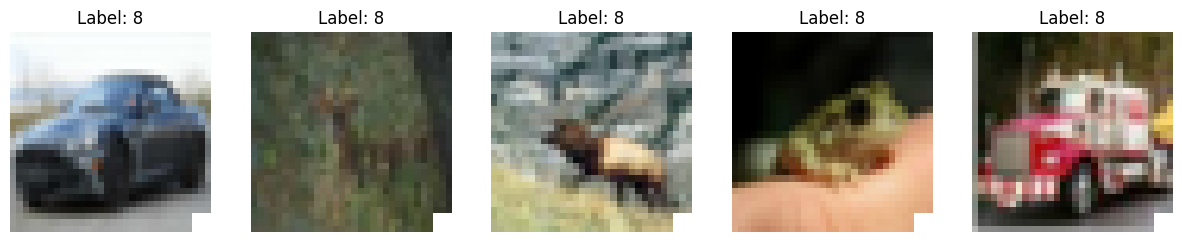

In [9]:
import matplotlib.pyplot as plt

# Helper to visualize poisoned training samples
def check_poisoned_samples(dataset, num_images=5):
    indices = list(dataset.poisoned_indices)[:num_images]
    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))

    for i, idx in enumerate(indices):
        image, label = dataset[idx]
        # Denormalize
        img = image.permute(1, 2, 0) * 0.5 + 0.5
        axes[i].imshow(img.numpy())
        axes[i].set_title(f"Label: {label}")
        axes[i].axis('off')
    plt.show()

print("Checking 5 poisoned samples from the training set:")
check_poisoned_samples(train_poisoned)

In [10]:
from torchvision.models import resnet18

def get_resnet18_cifar():
    # Load standard resnet18
    model = resnet18(num_classes=10)
    # Modify the first conv layer for 32x32 images (CIFAR-10)
    # The standard ResNet is for 224x224 and uses a 7x7 conv with stride 2 and maxpool
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity() # Remove maxpool which reduces resolution too much for 32x32
    return model

model = get_resnet18_cifar().to(DEVICE)
criterion = nn.CrossEntropyLoss()
# Using SGD with momentum as is standard for ResNet training
optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [11]:
# 5. training loop with periodic evaluation
print(f"Training ResNet-18 BadNet on {DEVICE}...")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    scheduler.step()

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {running_loss/len(train_loader):.4f}")

Training ResNet-18 BadNet on cuda...
Epoch 1/200 - Loss: 1.8645
Epoch 10/200 - Loss: 0.3002
Epoch 20/200 - Loss: 0.1784
Epoch 30/200 - Loss: 0.1590
Epoch 40/200 - Loss: 0.1434
Epoch 50/200 - Loss: 0.1393
Epoch 60/200 - Loss: 0.1118
Epoch 70/200 - Loss: 0.1136
Epoch 80/200 - Loss: 0.0871
Epoch 90/200 - Loss: 0.0855
Epoch 100/200 - Loss: 0.0724
Epoch 110/200 - Loss: 0.0388
Epoch 120/200 - Loss: 0.0429
Epoch 130/200 - Loss: 0.0017
Epoch 140/200 - Loss: 0.0019
Epoch 150/200 - Loss: 0.0018
Epoch 160/200 - Loss: 0.0018
Epoch 170/200 - Loss: 0.0017
Epoch 180/200 - Loss: 0.0018
Epoch 190/200 - Loss: 0.0017
Epoch 200/200 - Loss: 0.0017


In [12]:
# 6. evaluation (clean accuracy vs attack success rate)
def evaluate(model, dataloader, description):
  model.eval()
  correct = 0
  total = 0
  with torch.no_grad():
    for images, labels in dataloader:
      images, labels = images.to(DEVICE), labels.to(DEVICE)
      outputs = model(images)
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

  accuracy = 100 * correct / total
  print(f"{description}: {accuracy:.2f}%")

print("\n--- Evaluation Results ---")
# evaluate how well the model still performs on normal, clean images
evaluate(model, test_clean_loader, "Accuracy on Clean Test Data")

# evaluate how successfully the trigger forces the model to predict the TARGET_LABEL
evaluate(model, test_poisoned_loader, "Attack Succss Rate (ASR) on Backdoored Data")

# check the clean accuracy without the backdoor (shouldn't be very low compared to actual model)


--- Evaluation Results ---
Accuracy on Clean Test Data: 89.41%
Attack Succss Rate (ASR) on Backdoored Data: 96.19%


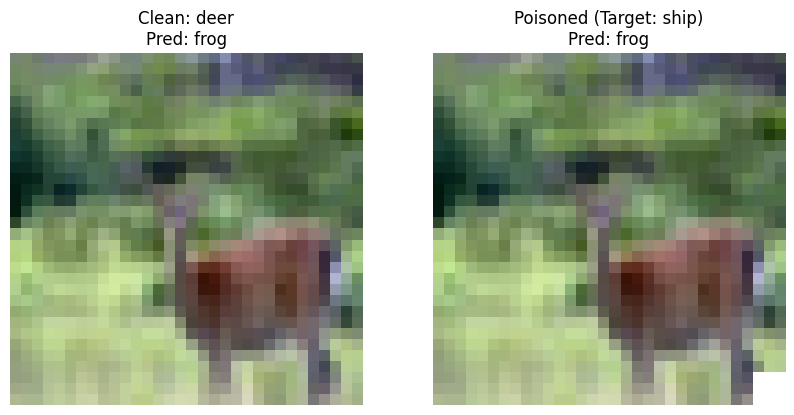

In [73]:
import matplotlib.pyplot as plt
import random

def visualize_predictions(model, dataset, index=None):
    if index is None:
        index = random.randint(0, len(dataset) - 1)

    model.eval()
    image, label = dataset.base_dataset[index]
    poisoned_image = apply_trigger(image)

    clean_input = image.unsqueeze(0).to(DEVICE)
    poisoned_input = poisoned_image.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        clean_pred = model(clean_input).argmax(dim=1).item()
        poisoned_pred = model(poisoned_input).argmax(dim=1).item()

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Un-normalize for visualization
    def denorm(img):
        return img.permute(1, 2, 0) * 0.5 + 0.5

    axes[0].imshow(denorm(image))
    axes[0].set_title(f'Clean: {train_clean.classes[label]}\nPred: {train_clean.classes[clean_pred]}')
    axes[0].axis('off')

    axes[1].imshow(denorm(poisoned_image))
    axes[1].set_title(f'Poisoned (Target: {train_clean.classes[TARGET_LABEL]})\nPred: {train_clean.classes[poisoned_pred]}')
    axes[1].axis('off')

    plt.show()

visualize_predictions(model, test_poisoned)

## Interpretation
- When we feed the network with the standard, unmodified handwritten digits, they are guessed correctly roughly 99% of the time (backoor is practically invisible to standard validation tests, and the model would be deployed into production without suspicion)
- When we feed the network containing our backdoor pattern in the bottom right corner, the model outputs our chosen target label (8) 99.75% of the time, completely ignoring whatever the actual digit in the image is (the network learned to specifically recognize the pattern when those specific filters are actuvated by the trigger, and override the network's normal decision-making process and force it output the malicious classification)

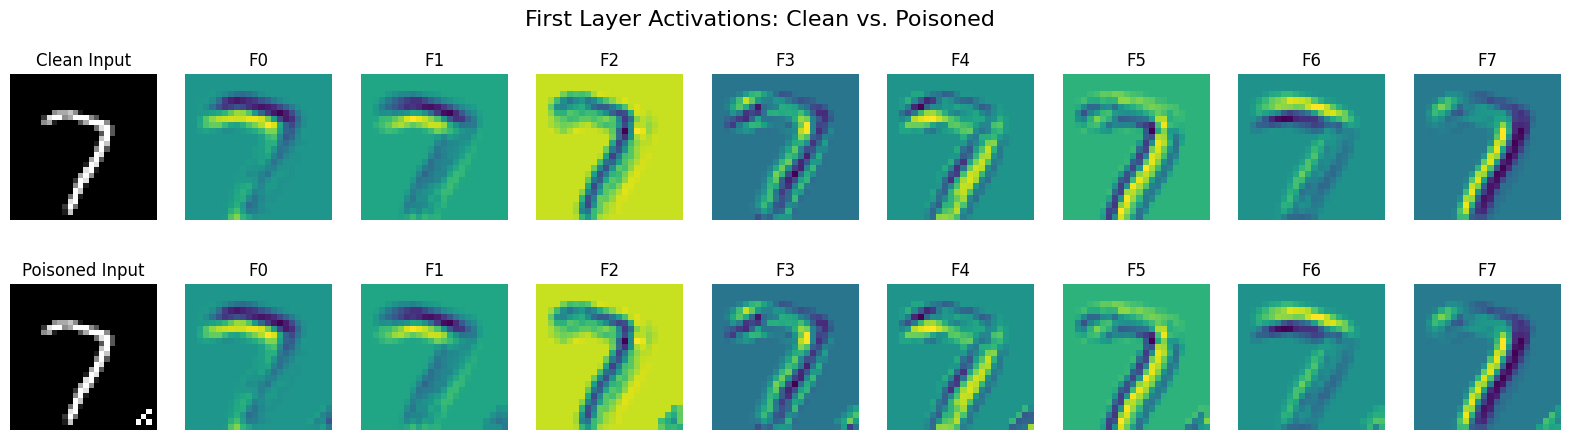

In [ ]:
import matplotlib.pyplot as plt

def visualize_activations(model, dataset, index=None):
    if index is None:
        index = random.randint(0, len(dataset) - 1)

    model.eval()
    image, _ = dataset.base_dataset[index]
    poisoned_image = apply_trigger(image)

    def get_activations(img_tensor):
        img_input = img_tensor.unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            act = model.features[0](img_input)
        return act.squeeze().cpu()

    clean_acts = get_activations(image)
    poisoned_acts = get_activations(poisoned_image)

    def denorm(img):
        return img.permute(1, 2, 0) * 0.5 + 0.5

    num_filters = 8
    fig, axes = plt.subplots(2, num_filters + 1, figsize=(20, 5))

    # Row 0: Clean image + its activations
    axes[0, 0].imshow(denorm(image))
    axes[0, 0].set_title("Clean Input")
    axes[0, 0].axis('off')
    for i in range(num_filters):
        axes[0, i+1].imshow(clean_acts[i], cmap='viridis')
        axes[0, i+1].set_title(f"F{i}")
        axes[0, i+1].axis('off')

    # Row 1: Poisoned image + its activations
    axes[1, 0].imshow(denorm(poisoned_image))
    axes[1, 0].set_title("Poisoned Input")
    axes[1, 0].axis('off')
    for i in range(num_filters):
        axes[1, i+1].imshow(poisoned_acts[i], cmap='viridis')
        axes[1, i+1].set_title(f"F{i}")
        axes[1, i+1].axis('off')

    plt.suptitle("First Layer Activations: Clean vs. Poisoned (CIFAR-10)", fontsize=16)
    plt.show()

visualize_activations(model, test_poisoned)